<center><h1>HW7</h1></center>

Name: xxx
<br>
Github Username: xxx
<br>
USC ID: xxx

## 1. Multi-class and Multi-Label Classification Using Support Vector Machines

Import packages

In [54]:
import pandas as pd
import numpy as np
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score,ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import EmpiricalCovariance
import statsmodels.api as sm
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from pathlib import Path
from scipy.stats import bootstrap
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold,cross_val_score
# from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder
from itertools import cycle
from sklearn.preprocessing import label_binarize
from sklearn.metrics import auc as sklearn_auc
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn import tree
from sklearn.tree import _tree
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.decomposition import PCA
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, hamming_loss
from collections import Counter
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.svm import LinearSVC


### (a) Download the Anuran Calls (MFCCs) Data Set

In [3]:
df = pd.read_csv('../Data/Frogs_MFCCs.csv')
X = df.drop(columns=['RecordID','Species','Genus','Family'])
y = df[['Species','Genus','Family']]
xtrain,xtest,ytrain,ytest = train_test_split(X,y,random_state=42,test_size=0.3)
xtrain = xtrain.reset_index(drop=True)
xtest  = xtest.reset_index(drop=True)
ytrain = ytrain.reset_index(drop=True)
ytest  = ytest.reset_index(drop=True)

In [4]:
xtrain

,MFCCs_ 1,MFCCs_ 2,MFCCs_ 3,MFCCs_ 4,MFCCs_ 5,MFCCs_ 6,MFCCs_ 7,MFCCs_ 8,MFCCs_ 9,MFCCs_10,...,MFCCs_13,MFCCs_14,MFCCs_15,MFCCs_16,MFCCs_17,MFCCs_18,MFCCs_19,MFCCs_20,MFCCs_21,MFCCs_22
0,1.000000,0.327476,0.282440,0.572211,0.096509,-0.036705,-0.082174,0.146604,0.297338,-0.120902,...,0.438532,-0.148451,-0.260375,0.178628,0.218024,-0.042083,-0.126511,-0.090279,0.096176,0.191697
1,1.000000,0.232818,-0.144331,-0.078909,-0.072467,0.255380,0.450215,0.261033,-0.168462,-0.281445,...,-0.108483,0.329984,0.274031,-0.157579,-0.291979,-0.042932,-0.009021,-0.032679,0.023912,0.041407
2,0.966443,0.455914,1.000000,0.541650,-0.412873,0.307099,0.235819,-0.064025,0.069728,-0.052552,...,-0.073050,-0.140994,0.162584,-0.007981,-0.049428,-0.053166,-0.026728,0.029443,0.019032,-0.105221
3,1.000000,0.257873,0.112807,0.527614,0.186094,0.043683,-0.163682,-0.014125,0.196527,0.018839,...,0.404813,-0.075488,-0.320882,0.024806,0.226971,0.034969,-0.106029,-0.147124,0.042627,0.250249
4,1.000000,0.401859,0.563219,0.578304,-0.126517,-0.058725,0.431806,0.066801,-0.321014,0.155569,...,-0.132244,0.190753,0.126674,-0.148049,-0.002891,0.157072,-0.015251,-0.055428,0.086927,0.086006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5031,1.000000,0.406366,0.268684,0.704863,0.358415,0.055376,-0.159812,0.065813,0.345068,0.175460,...,0.378497,-0.014091,-0.352985,0.015183,0.220504,0.054246,-0.069108,-0.174583,-0.032202,0.188263
5032,1.000000,0.634337,0.594395,0.403271,0.004960,0.037880,-0.065399,0.125276,0.106976,-0.223357,...,-0.228140,-0.274889,0.244973,0.096130,-0.140923,0.003646,0.007163,0.068718,0.047640,-0.179215
5033,1.000000,0.756413,0.732319,0.385807,-0.034821,0.073881,-0.058027,0.183775,0.219419,-0.445112,...,-0.177708,-0.311815,0.182382,0.030100,-0.182019,0.006296,-0.005868,0.029439,0.004783,-0.198014
5034,0.931410,0.626137,1.000000,0.375834,-0.223044,0.325943,0.121659,-0.092542,0.163365,-0.049382,...,-0.047610,-0.188463,0.102240,0.150353,-0.054750,-0.054434,0.108092,0.156994,-0.051681,-0.085656


### (b) Train a classifier for each label

#### (i) Research

exact match score is the proportion of samples whose entire set of predicted labels exactly matches the true set of labels.  
hamming loss: the fraction of incorrect labels (either a missing or an extra label) across all label positions.  
hamming score = 1 - hamming loss.

#### (ii) Train a SVM for each of the labels

In [23]:
param_grid ={
    'estimator__C':[0.1,1,10,100],
    'estimator__gamma':[0.001,0.01,0.1,1]
}
base = SVC(kernel='rbf',probability=True)###SVM
model = OneVsRestClassifier(base)

models={}
best_params = {}

for col in ['Family', 'Genus', 'Species']:
    grid = GridSearchCV(
    model,param_grid=param_grid,scoring='accuracy',cv=10,n_jobs=-1
    )
    grid.fit(xtrain,ytrain[col])

    models[col] = grid.best_estimator_
    best_params[col] = grid.best_params_





In [24]:
labels = ['Family', 'Genus', 'Species']
df_y = pd.DataFrame({
    col:models[col].predict(xtest) for col in labels
},columns = labels)
ytrue = ytest[labels].to_numpy()
y_pred = df_y[labels].to_numpy()

exact_match = np.mean(np.all(ytrue == y_pred,axis=1))
hamming_scores = 1-np.mean(ytrue!=y_pred)
print('the best params are:')
print(best_params)
print(f'exact match is {exact_match} and hamming_scores is {hamming_scores}')


the best params are:
{'Family': {'estimator__C': 100, 'estimator__gamma': 1}, 'Genus': {'estimator__C': 10, 'estimator__gamma': 1}, 'Species': {'estimator__C': 10, 'estimator__gamma': 1}}
exact match is 0.9874942102825383 and hamming_scores is 0.9922803767176162


In [25]:
scaler = StandardScaler()
xtrain_s = scaler.fit_transform(xtrain)
xtest_s = scaler.transform(xtest)
param_grid ={
    'estimator__C':[0.1,1,10,100],
    'estimator__gamma':[0.001,0.01,0.1,1]
}
base = SVC(kernel='rbf',probability=True)###SVM
model = OneVsRestClassifier(base)

models={}
best_params = {}

for col in ['Family', 'Genus', 'Species']:
    grid = GridSearchCV(
    model,param_grid=param_grid,scoring='accuracy',cv=10,n_jobs=-1
    )
    grid.fit(xtrain_s,ytrain[col])

    models[col] = grid.best_estimator_
    best_params[col] = grid.best_params_

labels = ['Family', 'Genus', 'Species']
df_y = pd.DataFrame({
    col:models[col].predict(xtest_s) for col in labels
},columns = labels)
ytrue = ytest[labels].to_numpy()
y_pred = df_y[labels].to_numpy()

exact_match = np.mean(np.all(ytrue == y_pred,axis=1))
hamming_scores = 1-np.mean(ytrue!=y_pred)
print('result for standardized')
print('the best params are:')
print(best_params)
print(f'exact match is {exact_match} and hamming_scores is {hamming_scores}')


result for standardized
the best params are:
{'Family': {'estimator__C': 10, 'estimator__gamma': 0.1}, 'Genus': {'estimator__C': 10, 'estimator__gamma': 0.1}, 'Species': {'estimator__C': 10, 'estimator__gamma': 0.1}}
exact match is 0.9865678554886521 and hamming_scores is 0.9899644897329011


#### (iii) Repeat 1(b)ii with L1-penalized SVMs

In [ ]:

param_grid ={
    'estimator__C':[0.1,1,10,100],
}
base =LinearSVC(penalty = 'l1',dual=False,max_iter=5000)###SVM
model = OneVsRestClassifier(base)

models={}
best_params = {}

for col in ['Family', 'Genus', 'Species']:
    grid = GridSearchCV(
    model,param_grid=param_grid,scoring='accuracy',cv=10,n_jobs=-1
    )
    grid.fit(xtrain_s,ytrain[col])###use x_s, already standardized

    models[col] = grid.best_estimator_
    best_params[col] = grid.best_params_

labels = ['Family', 'Genus', 'Species']
df_y = pd.DataFrame({
    col:models[col].predict(xtest_s) for col in labels
},columns = labels)
ytrue = ytest[labels].to_numpy()
y_pred = df_y[labels].to_numpy()

exact_match = np.mean(np.all(ytrue == y_pred,axis=1))
hamming_scores = 1-np.mean(ytrue!=y_pred)
print('result for standardized')
print('the best params are:')
print(best_params)
print(f'exact match is {exact_match} and hamming_scores is {hamming_scores}')

result for standardized
the best params are:
{'Family': {'estimator__C': 1}, 'Genus': {'estimator__C': 10}, 'Species': {'estimator__C': 10}}
exact match is 0.9129226493747105 and hamming_scores is 0.9431835726416551


#### (iv) Repeat 1(b)iii by using SMOTE or any other method for imbalance

In [29]:
scaler = StandardScaler()
xtrain_s = scaler.fit_transform(xtrain)
xtest_s = scaler.transform(xtest)
param_grid ={
    'estimator__C':[0.1,1,10]
}
base =LinearSVC(penalty = 'l1',dual=False,max_iter=5000)###SVM
model = OneVsRestClassifier(base)

models={}
best_params = {}

for col in ['Family', 'Genus', 'Species']:
    smote = SMOTE(random_state=42)
    xres,yres = smote.fit_resample(xtrain_s,ytrain[col])
    grid = GridSearchCV(
    model,param_grid=param_grid,scoring='accuracy',cv=10,n_jobs=-1
    )
    grid.fit(xres,yres)

    models[col] = grid.best_estimator_
    best_params[col] = grid.best_params_

labels = ['Family', 'Genus', 'Species']
df_y = pd.DataFrame({
    col:models[col].predict(xtest_s) for col in labels
},columns = labels)
ytrue = ytest[labels].to_numpy()
y_pred = df_y[labels].to_numpy()

exact_match = np.mean(np.all(ytrue == y_pred,axis=1))
hamming_scores = 1-np.mean(ytrue!=y_pred)
print('result for standardized')
print('the best params are:')
print(best_params)
print(f'exact match is {exact_match} and hamming_scores is {hamming_scores}')

result for standardized
the best params are:
{'Family': {'estimator__C': 10}, 'Genus': {'estimator__C': 10}, 'Species': {'estimator__C': 10}}
exact match is 0.8531727651690597 and hamming_scores is 0.9229581596418095


## 2. K-Means Clustering on a Multi-Class and Multi-Label Data Set

### (a) Use k-means clustering

In [ ]:


scores = []
for k in range(2,51):
    km = KMeans(n_clusters = k,random_state = 42)
    labels = km.fit_predict(X)
    scores.append(silhouette_score(X, labels))
best_k = range(2,51)[scores.index(max(scores))]
print(best_k)

4


### (b) Determine which family is the majority

In [ ]:

kmeans = KMeans(n_clusters=best_k,random_state=42)
clusters = kmeans.fit_predict(X)
df = pd.DataFrame({
    'cluster':clusters,
    'Family':y['Family'],
    'Genus':y['Genus'],
    'Species':y['Species']
})
for col in ['Family', 'Genus', 'Species']:
    print(f'{col}, majority for cluster')
    majoritylabel = (
        df.groupby('cluster')[col].apply(lambda x:Counter(x).most_common(1)[0]).to_dict()
    )
    for c, (label,count) in majoritylabel.items():
        print(f'cluster{c}: {label} has {count}')

Family, majority for cluster
cluster0: Leptodactylidae has 3467
cluster1: Hylidae has 590
cluster2: Dendrobatidae has 500
cluster3: Hylidae has 1245
Genus, majority for cluster
cluster0: Adenomera has 3466
cluster1: Hypsiboas has 542
cluster2: Ameerega has 500
cluster3: Hypsiboas has 1038
Species, majority for cluster
cluster0: AdenomeraHylaedactylus has 3466
cluster1: HypsiboasCinerascens has 452
cluster2: Ameeregatrivittata has 500
cluster3: HypsiboasCordobae has 1018


### (c) Calculate the average Hamming distance, Hamming score, and Hamming loss

In [47]:
labels = ['Family', 'Genus', 'Species']
majority_triplet = (
    df.groupby('cluster')[labels]
      .agg(lambda x: Counter(x).most_common(1)[0][0])   
      .to_dict(orient='index')
)
y_pred_df = df['cluster'].map(majority_triplet)
y_pred = pd.DataFrame(list(y_pred_df), columns=labels).reset_index(drop=True)
y_true = df[labels].reset_index(drop=True)
diff = (y_true != y_pred).astype(int)
samplewise_errors = diff.sum(axis=1)
avg_distance = samplewise_errors.mean()
hammingloss = diff.values.mean()
hammingscore = 1 - hammingloss


print(f"average Hamming distance: {avg_distance:.4f}")
print(f"hamming loss: {hammingloss}")
print(f"hamming score: {hammingscore}")

average Hamming distance: 0.6673
hamming loss: 0.2224229789205467
hamming score: 0.7775770210794533


## 3. ISLR 12.6.2

a

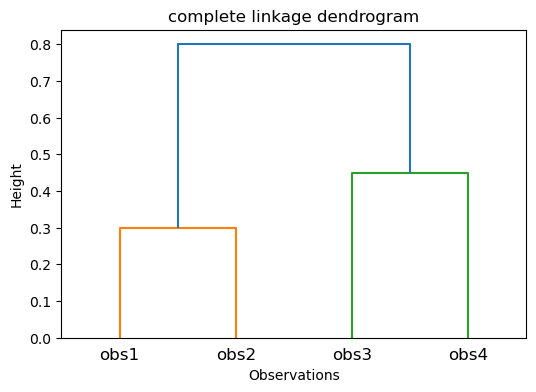

In [52]:
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
D = np.array([
    [0.0, 0.3, 0.4, 0.7],
    [0.3, 0.0, 0.5, 0.8],
    [0.4, 0.5, 0.0, 0.45],
    [0.7, 0.8, 0.45, 0.0]
])


condensed_D = squareform(D)

Z = linkage(condensed_D, method='complete')

plt.figure(figsize=(6, 4))
dendrogram(Z, labels=['obs1', 'obs2', 'obs3', 'obs4'])
plt.title("complete linkage dendrogram")
plt.xlabel("Observations")
plt.ylabel("Height")
plt.show()

b

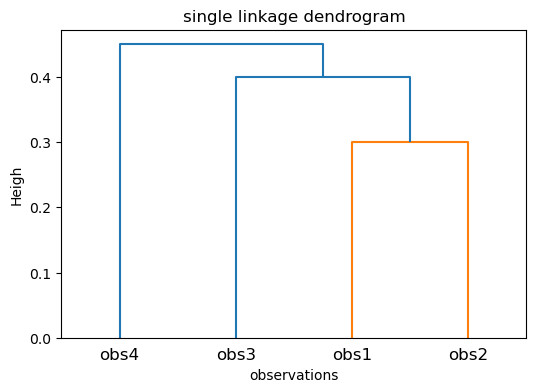

In [51]:
D = np.array([
    [0.0, 0.3, 0.4, 0.7],
    [0.3, 0.0, 0.5, 0.8],
    [0.4, 0.5, 0.0, 0.45],
    [0.7, 0.8, 0.45, 0.0]
])

condensed_D = squareform(D)

Z = linkage(condensed_D, method='single')
plt.figure(figsize=(6, 4))
dendrogram(Z, labels=['obs1', 'obs2', 'obs3', 'obs4'])
plt.title("single linkage dendrogram")
plt.xlabel("observations")
plt.ylabel("Heigh")
plt.show()

c

cluster 1: ob1 ob2  
cluster 2: ob3 ob4

d


cluster 1: ob1 ob2 ob3  
cluster 2: ob4

e

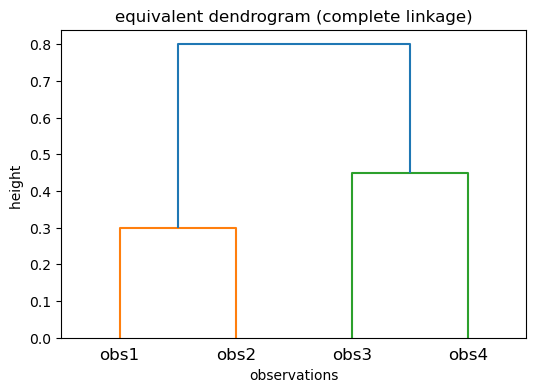

In [53]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

perm = [2, 3, 0, 1]  
D_perm = D[np.ix_(perm, perm)]
Z = linkage(squareform(D_perm), method='complete')

plt.figure(figsize=(6, 4))
dendrogram(Z, labels=['obs3', 'obs4', 'obs1', 'obs2'])
plt.title("equivalent dendrogram (complete linkage)")
plt.xlabel("observations")
plt.ylabel("height ")
plt.show()